# 🧠 Notebook 2: Baseline CNN-Transformer untuk Lokalisasi PVC/VT
## Perbandingan 3 Varian Transformer: Transformer Encoder, PatchTST, Hierarchical Transformer

**Pipeline:**
```
DATA DWT → SPLIT 80/20 → K-Fold 5 (pada 80% DWT)
  → CNN Feature Extractor (ekstraksi fitur)
  → 3 Transformer (lokalisasi): Encoder / PatchTST / Hierarchical
  → Perbandingan → Testing (20% DWT) → SHAP
```

**Metrik Evaluasi (sesuai Proposal TA):**
Accuracy, Sensitivity, Specificity, F1-Score, AUC-ROC, Confusion Matrix

---

## 1. Import Library & Konfigurasi

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, time, json, math, copy, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"✅ PyTorch {torch.__version__} | Device: {DEVICE}")

plt.rcParams.update({
    'figure.figsize': (16, 8), 'figure.dpi': 100, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'axes.grid': True, 'grid.alpha': 0.3,
})

BASE_DIR = Path('.')
PREPROCESSED_DIR = BASE_DIR / 'preprocessed_data'
DWT_DIR = PREPROCESSED_DIR / 'dwt_denoised'
RAW_ECG_DIR = BASE_DIR / 'PVCVTRawECGData'
OUTPUT_DIR = BASE_DIR / 'baseline_results'
OUTPUT_DIR.mkdir(exist_ok=True)

CONFIG = {
    'segment_length': 5000, 'sampling_rate': 1000, 'n_leads': 12,
    'n_folds': 5, 'batch_size': 32, 'epochs': 50,
    'learning_rate': 1e-3, 'weight_decay': 1e-4, 'patience': 10,
    'cnn_channels': [32, 64, 128, 256], 'cnn_kernels': [7, 5, 3, 3],
    'transformer_heads': 4, 'transformer_layers': 2,
    'transformer_dropout': 0.2, 'fc_dropout': 0.3,
    'patch_size': 16,  # untuk PatchTST
}

LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_COLORS = {
    'I': '#E63946', 'II': '#457B9D', 'III': '#2A9D8F',
    'aVR': '#E76F51', 'aVL': '#F4A261', 'aVF': '#264653',
    'V1': '#6A0572', 'V2': '#AB83A1', 'V3': '#F15BB5',
    'V4': '#00BBF9', 'V5': '#00F5D4', 'V6': '#FEE440',
}
MODEL_NAMES = ['Transformer Encoder', 'PatchTST', 'Hierarchical Transformer']
MODEL_COLORS = ['#2563EB', '#DC2626', '#059669']

print(f"\n📋 Konfigurasi:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")

✅ PyTorch 2.12.0 | Device: mps

📋 Konfigurasi:
   segment_length: 5000
   sampling_rate: 1000
   n_leads: 12
   n_folds: 5
   batch_size: 32
   epochs: 50
   learning_rate: 0.001
   weight_decay: 0.0001
   patience: 10
   cnn_channels: [32, 64, 128, 256]
   cnn_kernels: [7, 5, 3, 3]
   transformer_heads: 4
   transformer_layers: 2
   transformer_dropout: 0.2
   fc_dropout: 0.3
   patch_size: 16


---
## 2. Load Data dari Notebook 01

In [5]:
split_meta = pd.read_csv(PREPROCESSED_DIR / 'split_metadata.csv')
train_ids = np.load(PREPROCESSED_DIR / 'train_ids.npy', allow_pickle=True)
test_ids = np.load(PREPROCESSED_DIR / 'test_ids.npy', allow_pickle=True)
df_diag = pd.read_excel(BASE_DIR / 'Diagnosis.xlsx')

le = LabelEncoder()
le.fit(df_diag['LeftRight'].values)

print("=" * 70)
print("📂 DATA LOADED")
print("=" * 70)
print(f"   Total pasien    : {len(df_diag)}")
print(f"   Training (80%)  : {len(train_ids)} pasien")
print(f"   Testing  (20%)  : {len(test_ids)} pasien")
print(f"   Label classes   : {le.classes_} → {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"   ⚠️  Training & Testing keduanya menggunakan data DWT denoised")

📂 DATA LOADED
   Total pasien    : 334
   Training (80%)  : 267 pasien
   Testing  (20%)  : 67 pasien
   Label classes   : ['Left' 'Right'] → {'Left': np.int64(0), 'Right': np.int64(1)}
   ⚠️  Training & Testing keduanya menggunakan data DWT denoised


---
## 3. Preprocessing — Segmentation & Normalisasi

In [6]:
def load_ecg_signals(hospital_ids, ecg_dir, source_name=""):
    """Load sinyal EKG untuk list of hospital IDs."""
    signals, errors = {}, []
    for hid in hospital_ids:
        try:
            df = pd.read_csv(ecg_dir / f"{hid}.csv")
            signals[hid] = df[LEADS].values
        except Exception as e:
            errors.append((hid, str(e)))
    if errors:
        print(f"   ⚠️ {len(errors)} errors loading {source_name}")
    print(f"   ✅ Loaded {len(signals)} signals from {source_name}")
    return signals

def segment_signals(signals, labels_dict, segment_length=5000, overlap=0.5):
    """Potong sinyal menjadi segmen fixed-length dengan sliding window."""
    X_list, y_list, group_list = [], [], []
    step = int(segment_length * (1 - overlap))
    for hid, signal in signals.items():
        n_samples = len(signal)
        label = labels_dict[hid]
        if n_samples < segment_length:
            padded = np.zeros((segment_length, signal.shape[1]))
            padded[:n_samples] = signal
            X_list.append(padded.T)
            y_list.append(label)
            group_list.append(hid)
        else:
            start = 0
            while start + segment_length <= n_samples:
                segment = signal[start:start + segment_length]
                X_list.append(segment.T)
                y_list.append(label)
                group_list.append(hid)
                start += step
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(group_list)

In [7]:
# Load DWT denoised signals untuk TRAINING dan TESTING
print("⏳ Loading DWT denoised signals...")
train_signals = load_ecg_signals(train_ids, DWT_DIR, "DWT (train 80%)")
test_signals = load_ecg_signals(test_ids, DWT_DIR, "DWT (test 20%)")

label_dict = dict(zip(df_diag['HospitalID'].values,
                       le.transform(df_diag['LeftRight'].values)))

⏳ Loading DWT denoised signals...
   ✅ Loaded 267 signals from DWT (train 80%)
   ✅ Loaded 67 signals from DWT (test 20%)


In [8]:
print("\n⏳ Segmentasi sinyal...")
X_train_all, y_train_all, groups_train = segment_signals(
    train_signals, label_dict, CONFIG['segment_length'], overlap=0.5)
X_test_all, y_test_all, groups_test = segment_signals(
    test_signals, label_dict, CONFIG['segment_length'], overlap=0.5)

print(f"\n📊 Hasil Segmentasi:")
print(f"   Training: {X_train_all.shape}  labels={dict(zip(*np.unique(y_train_all, return_counts=True)))}")
print(f"   Testing : {X_test_all.shape}  labels={dict(zip(*np.unique(y_test_all, return_counts=True)))}")
print(f"   Train patients: {len(np.unique(groups_train))} | Test patients: {len(np.unique(groups_test))}")


⏳ Segmentasi sinyal...

📊 Hasil Segmentasi:
   Training: (2672, 12, 5000)  labels={np.int64(0): np.int64(475), np.int64(1): np.int64(2197)}
   Testing : (598, 12, 5000)  labels={np.int64(0): np.int64(126), np.int64(1): np.int64(472)}
   Train patients: 267 | Test patients: 67


In [9]:
print("\n⏳ Normalisasi (StandardScaler fit on training)...")
n_seg, n_leads, seg_len = X_train_all.shape
X_flat = X_train_all.transpose(0, 2, 1).reshape(-1, n_leads)
scaler = StandardScaler()
scaler.fit(X_flat)

X_train_scaled = scaler.transform(X_flat).reshape(n_seg, seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)
n_seg_t = X_test_all.shape[0]
X_test_flat = X_test_all.transpose(0, 2, 1).reshape(-1, n_leads)
X_test_scaled = scaler.transform(X_test_flat).reshape(n_seg_t, seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)

print(f"   Train scaled: {X_train_scaled.shape}, mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"   Test  scaled: {X_test_scaled.shape}")


⏳ Normalisasi (StandardScaler fit on training)...
   Train scaled: (2672, 12, 5000), mean=0.0000, std=1.0000
   Test  scaled: (598, 12, 5000)


---
## 4. K-Fold Cross-Validation Setup

In [10]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

skgf = StratifiedGroupKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)

print("=" * 70)
print(f"📊 {CONFIG['n_folds']}-FOLD STRATIFIED GROUP K-FOLD")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(skgf.split(X_train_scaled, y_train_all, groups_train)):
    tp = np.unique(groups_train[train_idx])
    vp = np.unique(groups_train[val_idx])
    assert len(set(tp) & set(vp)) == 0, "DATA LEAKAGE!"
    yt, yv = y_train_all[train_idx], y_train_all[val_idx]
    print(f"   Fold {fold+1}: Train {len(train_idx)} seg ({len(tp)} pat) | "
          f"Val {len(val_idx)} seg ({len(vp)} pat) | ✅ No leakage")

📊 5-FOLD STRATIFIED GROUP K-FOLD
   Fold 1: Train 2137 seg (214 pat) | Val 535 seg (53 pat) | ✅ No leakage
   Fold 2: Train 2138 seg (214 pat) | Val 534 seg (53 pat) | ✅ No leakage
   Fold 3: Train 2137 seg (213 pat) | Val 535 seg (54 pat) | ✅ No leakage
   Fold 4: Train 2138 seg (214 pat) | Val 534 seg (53 pat) | ✅ No leakage
   Fold 5: Train 2138 seg (213 pat) | Val 534 seg (54 pat) | ✅ No leakage


---
## 5. Model Architectures

### Arsitektur:
1. **CNN Feature Extractor** (shared) — ekstraksi fitur spasial/morfologi
2. **Transformer Encoder** — pemodelan dependensi global
3. **PatchTST** — pemodelan lokal-global berbasis patching
4. **Hierarchical Transformer** — pembelajaran multi-skala hierarkis

In [11]:
# ═══════════════════════════════════════════════════════
# 5a. CNN FEATURE EXTRACTOR (Shared untuk semua Transformer)
# ═══════════════════════════════════════════════════════

class CNNFeatureExtractor(nn.Module):
    """
    CNN 1D untuk ekstraksi fitur dari sinyal EKG 12-lead.
    Input:  (batch, 12, 5000)
    Output: (batch, 256, seq_len) — feature maps
    
    CNN HANYA bertugas mengekstrak fitur spasial dan morfologi.
    Fitur ini kemudian diumpankan ke Transformer untuk klasifikasi.
    """
    def __init__(self, in_channels=12, channels=[32, 64, 128, 256], kernels=[7, 5, 3, 3]):
        super().__init__()
        layers = []
        prev_ch = in_channels
        for ch, k in zip(channels, kernels):
            layers.extend([
                nn.Conv1d(prev_ch, ch, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(ch),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2, stride=2),
            ])
            prev_ch = ch
        self.features = nn.Sequential(*layers)
        self.out_channels = channels[-1]

    def forward(self, x):
        return self.features(x)  # (batch, 256, 312)

In [12]:
# ═══════════════════════════════════════════════════════
# 5b. POSITIONAL ENCODING (Shared)
# ═══════════════════════════════════════════════════════

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

In [13]:
# ═══════════════════════════════════════════════════════
# 5c. MODEL 1: CNN + TRANSFORMER ENCODER
# ═══════════════════════════════════════════════════════

class CNNTransformerEncoder(nn.Module):
    """
    CNN → Transformer Encoder → Classification.
    Transformer Encoder untuk pemodelan dependensi global.
    """
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        self.pos_enc = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['transformer_layers'])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, 2))

    def forward(self, x):
        features = self.cnn(x)              # (B, 256, 312)
        features = features.permute(0, 2, 1)  # (B, 312, 256) — seq for Transformer
        features = self.pos_enc(features)
        features = self.transformer(features)  # (B, 312, 256)
        pooled = features.mean(dim=1)          # GAP → (B, 256)
        return self.classifier(pooled)

In [14]:
# ═══════════════════════════════════════════════════════
# 5d. MODEL 2: CNN + PatchTST
# ═══════════════════════════════════════════════════════

class CNNPatchTST(nn.Module):
    """
    CNN → PatchTST → Classification.
    PatchTST: membagi sequence dari CNN menjadi patch-patch,
    lalu menggunakan Transformer untuk pemodelan lokal-global.
    Referensi: Nie et al. (2023) "A Time Series is Worth 64 Words"
    """
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.patch_size = config['patch_size']
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])

        # Patch embedding: linear projection dari patch ke d_model
        self.patch_proj = nn.Linear(self.patch_size * d_model, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=config['transformer_dropout'])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['transformer_layers'])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, 2))

    def forward(self, x):
        features = self.cnn(x)              # (B, 256, seq_len)
        features = features.permute(0, 2, 1)  # (B, seq_len, 256)
        B, S, D = features.shape

        # Truncate agar habis dibagi patch_size
        n_patches = S // self.patch_size
        features = features[:, :n_patches * self.patch_size, :]

        # Reshape ke patches: (B, n_patches, patch_size * d_model)
        patches = features.reshape(B, n_patches, self.patch_size * D)

        # Project patches ke d_model
        patches = self.patch_proj(patches)  # (B, n_patches, d_model)
        patches = self.pos_enc(patches)
        patches = self.transformer(patches)  # (B, n_patches, d_model)

        pooled = patches.mean(dim=1)  # GAP → (B, d_model)
        return self.classifier(pooled)

In [15]:
# ═══════════════════════════════════════════════════════
# 5e. MODEL 3: CNN + HIERARCHICAL TRANSFORMER
# ═══════════════════════════════════════════════════════

class CNNHierarchicalTransformer(nn.Module):
    """
    CNN → Hierarchical Transformer → Classification.
    Multi-scale: Level 1 (local) → Downsample → Level 2 (global).
    Referensi: Tang et al. (2024) "Hierarchical Transformer for ECG Diagnosis"
    """
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])

        # Level 1: Local Transformer (fine-grained)
        self.pos_enc_1 = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        enc_layer_1 = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer_level1 = nn.TransformerEncoder(enc_layer_1, num_layers=1)

        # Downsampling: Conv1d untuk mengurangi sequence length 2x
        self.downsample = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True))

        # Level 2: Global Transformer (coarse-grained)
        self.pos_enc_2 = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        enc_layer_2 = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer_level2 = nn.TransformerEncoder(enc_layer_2, num_layers=1)

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, 2))

    def forward(self, x):
        features = self.cnn(x)                # (B, 256, seq_len)
        seq = features.permute(0, 2, 1)       # (B, seq_len, 256)

        # Level 1: Local Transformer
        seq = self.pos_enc_1(seq)
        local_out = self.transformer_level1(seq)  # (B, seq_len, 256)

        # Downsample: reduce sequence length
        ds = local_out.permute(0, 2, 1)       # (B, 256, seq_len)
        ds = self.downsample(ds)              # (B, 256, seq_len//2)
        ds = ds.permute(0, 2, 1)              # (B, seq_len//2, 256)

        # Level 2: Global Transformer
        ds = self.pos_enc_2(ds)
        global_out = self.transformer_level2(ds)  # (B, seq_len//2, 256)

        pooled = global_out.mean(dim=1)       # GAP → (B, 256)
        return self.classifier(pooled)

In [16]:
# Verifikasi semua arsitektur
print("=" * 70)
print("🧠 VERIFIKASI ARSITEKTUR MODEL")
print("=" * 70)

model_classes = [CNNTransformerEncoder, CNNPatchTST, CNNHierarchicalTransformer]
dummy = torch.randn(2, 12, 5000).to(DEVICE)

for name, ModelClass in zip(MODEL_NAMES, model_classes):
    model = ModelClass(CONFIG).to(DEVICE)
    out = model(dummy)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\n   {name}:")
    print(f"     Output shape: {out.shape}")
    print(f"     Parameters  : {n_params:,}")
    del model

del dummy
print(f"\n✅ Semua model terverifikasi!")

🧠 VERIFIKASI ARSITEKTUR MODEL

   Transformer Encoder:
     Output shape: torch.Size([2, 2])
     Parameters  : 1,750,434

   PatchTST:
     Output shape: torch.Size([2, 2])
     Parameters  : 2,799,266

   Hierarchical Transformer:
     Output shape: torch.Size([2, 2])
     Parameters  : 1,947,810

✅ Semua model terverifikasi!


---
## 6. Training Functions

In [17]:
def compute_metrics(y_true, y_pred, y_prob):
    """Hitung metrik sesuai proposal: Accuracy, Sensitivity, Specificity, F1, AUC-ROC."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    acc = (tp + tn) / (tp + fp + fn + tn) if (tp + fp + fn + tn) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0
    return {'accuracy': acc, 'sensitivity': sensitivity, 'specificity': specificity,
            'f1': f1, 'auc': auc, 'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct += out.argmax(1).eq(y_b).sum().item()
        total += len(y_b)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_probs, all_labels = 0, [], [], []
    total = 0
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out = model(X_b)
            loss = criterion(out, y_b)
            total_loss += loss.item() * len(y_b)
            total += len(y_b)
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())
    preds, probs, labels = np.array(all_preds), np.array(all_probs), np.array(all_labels)
    metrics = compute_metrics(labels, preds, probs)
    metrics['loss'] = total_loss / total
    return metrics, preds, probs, labels

In [18]:
# Class weights untuk imbalance
n_class0 = (y_train_all == 0).sum()
n_class1 = (y_train_all == 1).sum()
class_weights = torch.FloatTensor([1.0 / n_class0, 1.0 / n_class1])
class_weights = class_weights / class_weights.sum() * 2
print(f"📊 Class weights: {le.classes_[0]}={class_weights[0]:.3f}, {le.classes_[1]}={class_weights[1]:.3f}")

📊 Class weights: Left=1.644, Right=0.356


---
## 7. K-Fold Training — 3 Model Transformer

In [19]:
print("=" * 70)
print(f"🚀 TRAINING {CONFIG['n_folds']}-FOLD CV × 3 MODEL TRANSFORMER")
print("=" * 70)

all_results = {}  # {model_name: [fold_metrics]}
all_histories = {}  # {model_name: [fold_history]}
all_best_models = {}  # {model_name: [fold_state_dict]}

for model_idx, (model_name, ModelClass) in enumerate(zip(MODEL_NAMES, model_classes)):
    print(f"\n{'═'*70}")
    print(f"🧠 MODEL {model_idx+1}/3: {model_name}")
    print(f"{'═'*70}")

    fold_results = []
    fold_histories = []
    fold_best_models = []

    for fold, (train_idx, val_idx) in enumerate(skgf.split(X_train_scaled, y_train_all, groups_train)):
        print(f"\n   ── Fold {fold+1}/{CONFIG['n_folds']} ──")
        X_ft, y_ft = X_train_scaled[train_idx], y_train_all[train_idx]
        X_fv, y_fv = X_train_scaled[val_idx], y_train_all[val_idx]

        train_loader = DataLoader(ECGDataset(X_ft, y_ft), batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
        val_loader = DataLoader(ECGDataset(X_fv, y_fv), batch_size=CONFIG['batch_size'], shuffle=False)

        model = ModelClass(CONFIG).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
        optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

        best_f1, patience_cnt, best_state, best_ep = 0, 0, None, 0
        history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

        for epoch in range(CONFIG['epochs']):
            t0 = time.time()
            tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            val_m, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
            scheduler.step()

            history['train_loss'].append(tr_loss)
            history['val_loss'].append(val_m['loss'])
            history['val_acc'].append(val_m['accuracy'])
            history['val_f1'].append(val_m['f1'])
            history['val_auc'].append(val_m['auc'])

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"      Ep {epoch+1:3d} | TrLoss {tr_loss:.4f} | "
                      f"ValAcc {val_m['accuracy']:.3f} | ValF1 {val_m['f1']:.3f} | "
                      f"ValAUC {val_m['auc']:.3f} | {time.time()-t0:.1f}s")

            if val_m['f1'] > best_f1:
                best_f1 = val_m['f1']
                patience_cnt = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_ep = epoch + 1
            else:
                patience_cnt += 1
                if patience_cnt >= CONFIG['patience']:
                    print(f"      ⏹️ Early stop ep {epoch+1} (best: {best_ep})")
                    break

        model.load_state_dict(best_state)
        model.to(DEVICE)
        final_m, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        final_m['fold'] = fold + 1
        final_m['best_epoch'] = best_ep
        fold_results.append(final_m)
        fold_histories.append(history)
        fold_best_models.append(best_state)

        print(f"      ✅ Best ep {best_ep}: Acc={final_m['accuracy']:.3f} Sens={final_m['sensitivity']:.3f} "
              f"Spec={final_m['specificity']:.3f} F1={final_m['f1']:.3f} AUC={final_m['auc']:.3f}")

    all_results[model_name] = fold_results
    all_histories[model_name] = fold_histories
    all_best_models[model_name] = fold_best_models

🚀 TRAINING 5-FOLD CV × 3 MODEL TRANSFORMER

══════════════════════════════════════════════════════════════════════
🧠 MODEL 1/3: Transformer Encoder
══════════════════════════════════════════════════════════════════════

   ── Fold 1/5 ──
      Ep   1 | TrLoss 0.5939 | ValAcc 0.849 | ValF1 0.909 | ValAUC 0.852 | 11.8s
      Ep  10 | TrLoss 0.4692 | ValAcc 0.886 | ValF1 0.935 | ValAUC 0.907 | 11.4s
      Ep  20 | TrLoss 0.4542 | ValAcc 0.884 | ValF1 0.933 | ValAUC 0.823 | 11.7s
      Ep  30 | TrLoss 0.3809 | ValAcc 0.880 | ValF1 0.927 | ValAUC 0.910 | 11.6s
      ⏹️ Early stop ep 34 (best: 24)
      ✅ Best ep 24: Acc=0.910 Sens=0.982 Spec=0.583 F1=0.947 AUC=0.865

   ── Fold 2/5 ──
      Ep   1 | TrLoss 0.5562 | ValAcc 0.897 | ValF1 0.937 | ValAUC 0.912 | 11.7s
      Ep  10 | TrLoss 0.4542 | ValAcc 0.858 | ValF1 0.920 | ValAUC 0.819 | 11.6s
      Ep  20 | TrLoss 0.3876 | ValAcc 0.899 | ValF1 0.942 | ValAUC 0.918 | 11.7s
      ⏹️ Early stop ep 22 (best: 12)
      ✅ Best ep 12: Acc=0.906 S

---
## 8. Perbandingan 3 Model — K-Fold Results

In [20]:
print("=" * 70)
print("📊 PERBANDINGAN K-FOLD CV — 3 MODEL TRANSFORMER")
print("=" * 70)

comparison_data = []
for model_name in MODEL_NAMES:
    df_r = pd.DataFrame(all_results[model_name])
    row = {'Model': model_name}
    for m in ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']:
        row[f'{m}_mean'] = df_r[m].mean()
        row[f'{m}_std'] = df_r[m].std()
    
    # Calculate average best epoch for final training
    avg_best_epoch = int(np.round(df_r['best_epoch'].mean()))
    row['avg_best_epoch'] = avg_best_epoch
    
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

# Print table
metrics_list = ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']
print(f"\n{'Model':<28}", end="")
for m in metrics_list:
    print(f" {m.capitalize():<16}", end="")
print(f" {'AvgBestEp':<10}")
print("─" * 120)
for _, row in df_comparison.iterrows():
    print(f"{row['Model']:<28}", end="")
    for m in metrics_list:
        print(f" {row[f'{m}_mean']:.3f}±{row[f'{m}_std']:.3f}     ", end="")
    print(f" {row['avg_best_epoch']:<10.0f}")

# Best model
best_model_name = df_comparison.loc[df_comparison['f1_mean'].idxmax(), 'Model']
best_avg_epoch = df_comparison.loc[df_comparison['f1_mean'].idxmax(), 'avg_best_epoch']
best_idx = MODEL_NAMES.index(best_model_name)
print(f"\n🏆 Best Model (by F1): {best_model_name} (Avg Best Epoch: {best_avg_epoch})")

📊 PERBANDINGAN K-FOLD CV — 3 MODEL TRANSFORMER

Model                        Accuracy         Sensitivity      Specificity      F1               Auc              AvgBestEp 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Transformer Encoder          0.902±0.023      0.974±0.019      0.572±0.063      0.942±0.014      0.834±0.080      12        
PatchTST                     0.905±0.020      0.976±0.019      0.574±0.156      0.944±0.011      0.847±0.065      13        
Hierarchical Transformer     0.912±0.027      0.968±0.021      0.650±0.096      0.947±0.016      0.870±0.057      9         

🏆 Best Model (by F1): Hierarchical Transformer (Avg Best Epoch: 9)


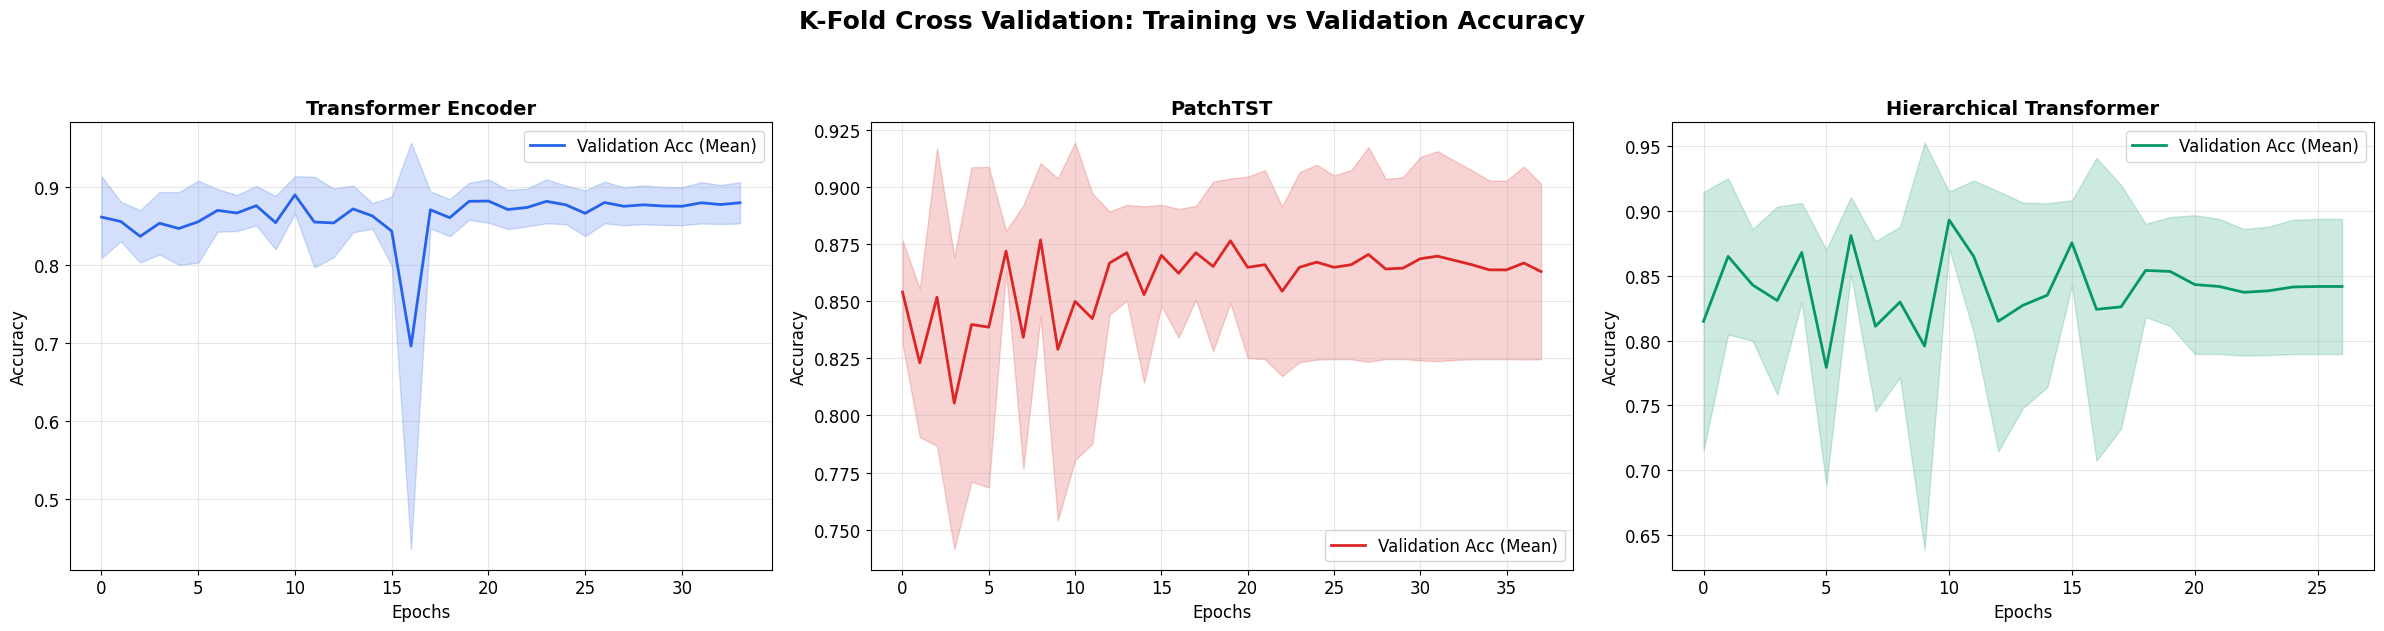

In [21]:
# Visualisasi perbandingan Training vs Validation selama K-Fold
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('K-Fold Cross Validation: Training vs Validation Accuracy', fontsize=18, fontweight='bold', y=1.05)

for i, model_name in enumerate(MODEL_NAMES):
    ax = axes[i]
    color = MODEL_COLORS[i]
    
    # Ambil history dari 5 fold
    histories = all_histories[model_name]
    max_len = max(len(h['val_acc']) for h in histories)
    
    # Pad array
    val_accs = np.array([h['val_acc'] + [h['val_acc'][-1]]*(max_len - len(h['val_acc'])) for h in histories])
    
    mean_val = np.mean(val_accs, axis=0)
    std_val = np.std(val_accs, axis=0)
    
    epochs = np.arange(max_len)
    ax.plot(epochs, mean_val, color=color, linewidth=2, label='Validation Acc (Mean)')
    ax.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.2, color=color)
    
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'kfold_train_val_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Final Model Training

**PENTING:** Melatih ulang model terbaik ({best_model_name}) menggunakan **seluruh 80% data training** sebanyak rata-rata best epoch ({best_avg_epoch}), tanpa validation split lagi.

🔥 FINAL MODEL TRAINING (Hierarchical Transformer)
   Menggunakan 100% dari data training (N=2672)
   Target Epochs: 9
   Ep   1/9 | TrLoss 0.5012 | TrAcc 0.834 | 11.2s
   Ep   5/9 | TrLoss 0.3966 | TrAcc 0.895 | 11.0s
   Ep   9/9 | TrLoss 0.3935 | TrAcc 0.883 | 11.1s

✅ Final Model Training Selesai!


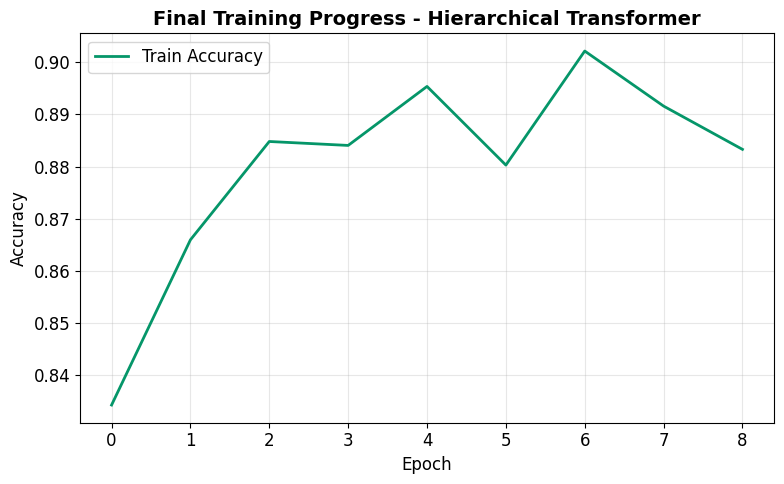

In [22]:
print("=" * 70)
print(f"🔥 FINAL MODEL TRAINING ({best_model_name})")
print(f"   Menggunakan 100% dari data training (N={len(X_train_scaled)})")
print(f"   Target Epochs: {best_avg_epoch}")
print("=" * 70)

# Initialize best model architecture fresh
final_model = model_classes[best_idx](CONFIG).to(DEVICE)
criterion_final = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer_final = optim.AdamW(final_model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])

# DataLoader untuk seluruh data training 80%
final_train_loader = DataLoader(
    ECGDataset(X_train_scaled, y_train_all), 
    batch_size=CONFIG['batch_size'], 
    shuffle=True, 
    drop_last=True
)

final_history = {'train_loss': [], 'train_acc': []}

for epoch in range(best_avg_epoch):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(final_model, final_train_loader, criterion_final, optimizer_final, DEVICE)
    
    final_history['train_loss'].append(tr_loss)
    final_history['train_acc'].append(tr_acc)
    
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == best_avg_epoch - 1:
        print(f"   Ep {epoch+1:3d}/{best_avg_epoch} | TrLoss {tr_loss:.4f} | TrAcc {tr_acc:.3f} | {time.time()-t0:.1f}s")

print("\n✅ Final Model Training Selesai!")

# Visualisasi Final Training
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(final_history['train_acc'], color='#059669', label='Train Accuracy', linewidth=2)
ax.set_title(f'Final Training Progress - {best_model_name}', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Final Testing (20% DWT Data)

Menggunakan **Final Model** yang baru saja dilatih pada 20% data testing yang tidak pernah dilihat sebelumnya.

In [23]:
print("=" * 70)
print(f"🧪 FINAL TESTING — 20% DWT DATA ({len(X_test_scaled)} segments)")
print("=" * 70)

final_model.eval()

# Test DataLoader
test_loader = DataLoader(ECGDataset(X_test_scaled, y_test_all), batch_size=CONFIG['batch_size'], shuffle=False)

# Evaluasi tingkat segmen
test_metrics, test_preds, test_probs, test_labels = evaluate(
    final_model, test_loader, nn.CrossEntropyLoss(), DEVICE
)

print("\n📊 Segment-Level Metrics:")
for m in ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']:
    print(f"   {m.capitalize():<12}: {test_metrics[m]:.3f}")

🧪 FINAL TESTING — 20% DWT DATA (598 segments)

📊 Segment-Level Metrics:
   Accuracy    : 0.831
   Sensitivity : 0.847
   Specificity : 0.770
   F1          : 0.888
   Auc         : 0.907


In [24]:
# Patient-level majority voting
print("\n📊 Patient-Level Majority Voting:")

patient_preds = {}
patient_probs = {}
patient_true = {}

for i, hid in enumerate(groups_test):
    if hid not in patient_preds:
        patient_preds[hid] = []
        patient_probs[hid] = []
        patient_true[hid] = test_labels[i]
    patient_preds[hid].append(test_preds[i])
    patient_probs[hid].append(test_probs[i])

patient_final_preds = {}
patient_final_probs = {}
for hid in patient_preds:
    votes = np.array(patient_preds[hid])
    patient_final_preds[hid] = int(np.round(votes.mean()))
    patient_final_probs[hid] = np.mean(patient_probs[hid])

y_true_patient = np.array([patient_true[hid] for hid in patient_preds])
y_pred_patient = np.array([patient_final_preds[hid] for hid in patient_preds])
y_prob_patient = np.array([patient_final_probs[hid] for hid in patient_preds])

patient_metrics = compute_metrics(y_true_patient, y_pred_patient, y_prob_patient)

print(f"   Total test patients: {len(y_true_patient)}")
for m in ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']:
    print(f"   {m.capitalize():<12}: {patient_metrics[m]:.3f}")

print(f"\n📋 Classification Report (Patient-Level):")
print(classification_report(y_true_patient, y_pred_patient, target_names=le.classes_))


📊 Patient-Level Majority Voting:
   Total test patients: 67
   Accuracy    : 0.866
   Sensitivity : 0.885
   Specificity : 0.800
   F1          : 0.911
   Auc         : 0.944

📋 Classification Report (Patient-Level):
              precision    recall  f1-score   support

        Left       0.67      0.80      0.73        15
       Right       0.94      0.88      0.91        52

    accuracy                           0.87        67
   macro avg       0.80      0.84      0.82        67
weighted avg       0.88      0.87      0.87        67



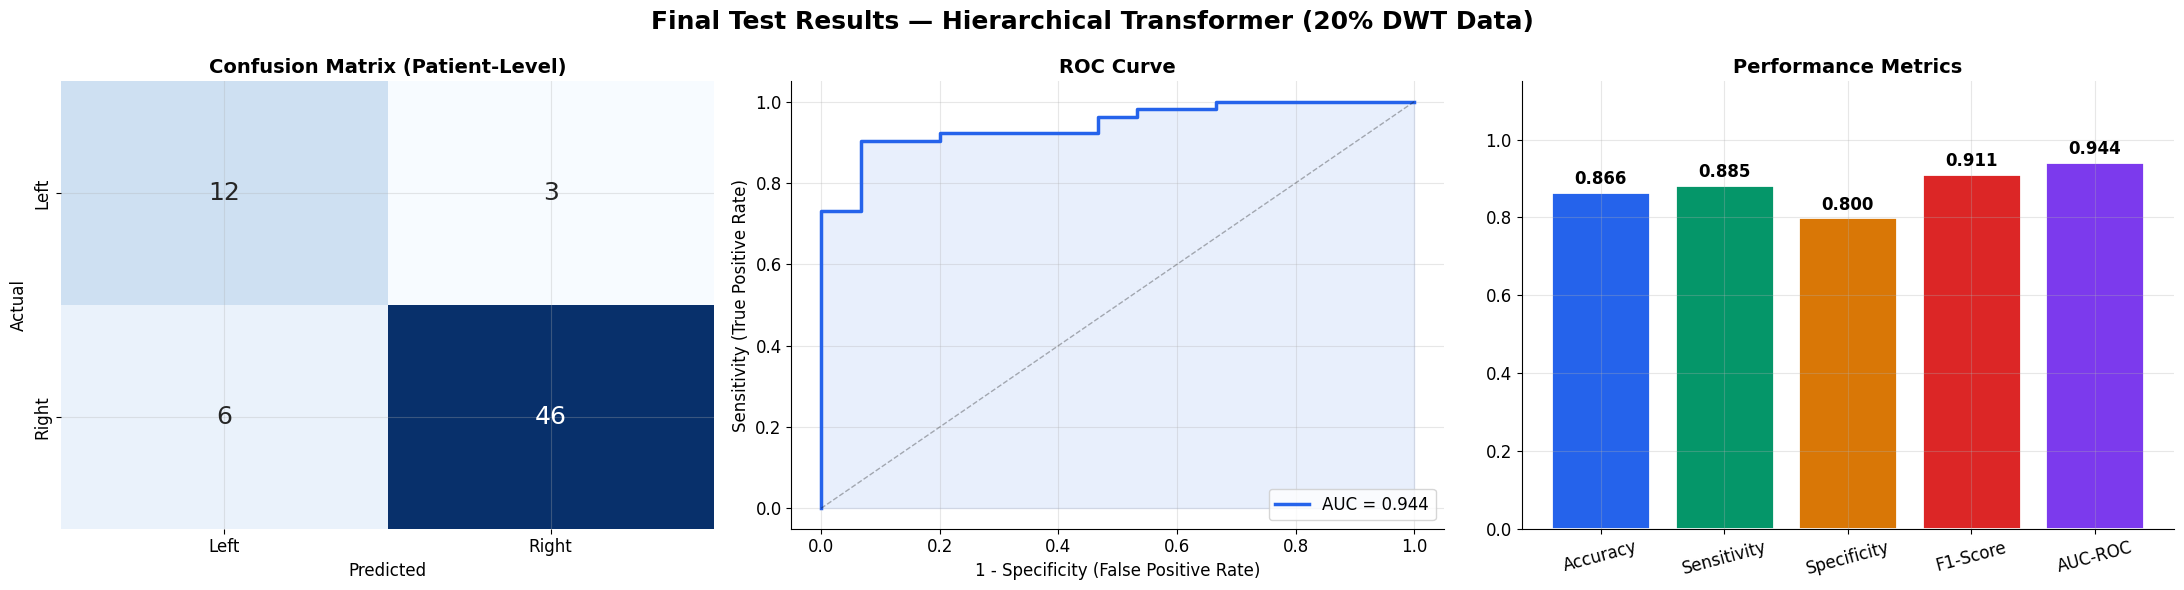

In [25]:
# Visualisasi Metrik Akhir
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(f'Final Test Results — {best_model_name} (20% DWT Data)', fontsize=18, fontweight='bold')

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_true_patient, y_pred_patient)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_,
            annot_kws={'size': 18}, cbar=False)
ax.set_title('Confusion Matrix (Patient-Level)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)

# ROC Curve
ax = axes[1]
fpr, tpr, thresholds = roc_curve(y_true_patient, y_prob_patient)
ax.plot(fpr, tpr, color='#2563EB', linewidth=2.5, label=f'AUC = {patient_metrics["auc"]:.3f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
ax.fill_between(fpr, tpr, alpha=0.1, color='#2563EB')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.set_xlabel('1 - Specificity (False Positive Rate)')
ax.set_ylabel('Sensitivity (True Positive Rate)')
ax.legend(fontsize=12, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

# Bar chart metrik
ax = axes[2]
m_names = ['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'AUC-ROC']
m_keys = ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']
m_vals = [patient_metrics[k] for k in m_keys]
colors_m = ['#2563EB', '#059669', '#D97706', '#DC2626', '#7C3AED']

bars = ax.bar(m_names, m_vals, color=colors_m, edgecolor='white', linewidth=2)
for bar, val in zip(bars, m_vals):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'final_test_results.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. SHAP Explainability (Model Utama)

Menggunakan SHAP GradientExplainer untuk analisis interpretability pada model Final.

In [26]:
import shap

print("=" * 70)
print(f"🔍 SHAP EXPLAINABILITY ANALYSIS ({best_model_name})")
print("=" * 70)

np.random.seed(SEED)
bg_idx = np.random.choice(len(X_train_scaled), size=min(100, len(X_train_scaled)), replace=False)
background = torch.FloatTensor(X_train_scaled[bg_idx]).to(DEVICE)

n_exp = min(50, len(X_test_scaled))
exp_idx = np.random.choice(len(X_test_scaled), size=n_exp, replace=False)
exp_data = torch.FloatTensor(X_test_scaled[exp_idx]).to(DEVICE)
exp_labels = y_test_all[exp_idx]

print("\n⏳ Computing SHAP values (GradientExplainer)...")
final_model.eval()

try:
    explainer = shap.GradientExplainer(final_model, background)
    shap_values = explainer.shap_values(exp_data)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values
    print("✅ SHAP computed successfully!")
except Exception as e:
    print(f"⚠️ SHAP GradientExplainer failed: {e}")
    print("   Falling back to manual gradient-based importance...")
    exp_data_grad = exp_data.clone().requires_grad_(True)
    out = final_model(exp_data_grad)
    out[:, 1].sum().backward()
    shap_vals = exp_data_grad.grad.cpu().numpy()
    print("✅ Gradient-based importance computed!")

# Pastikan shap_vals 3D (N, 12, L) untuk kelas target (indeks 1)
if len(shap_vals.shape) == 4:
    shap_vals = shap_vals[..., 1]

🔍 SHAP EXPLAINABILITY ANALYSIS (Hierarchical Transformer)

⏳ Computing SHAP values (GradientExplainer)...
✅ SHAP computed successfully!


In [27]:
# Analisis per-lead importance (Bar Chart Sederhana)
lead_imp = np.abs(shap_vals).mean(axis=(0, 2))
lead_imp_df = pd.DataFrame({'Lead': LEADS, 'Importance': lead_imp}).sort_values('Importance', ascending=False)

print(f"\n{'Lead':<8} {'Importance':<12}")
print("─" * 20)
for _, row in lead_imp_df.iterrows():
    bar = '█' * int(row['Importance'] / lead_imp_df['Importance'].max() * 30)
    print(f"{row['Lead']:<8} {row['Importance']:<12.6f} {bar}")


Lead     Importance  
────────────────────
V2       0.000421     ██████████████████████████████
V4       0.000336     ███████████████████████
V6       0.000241     █████████████████
aVR      0.000191     █████████████
V3       0.000189     █████████████
V1       0.000168     ███████████
V5       0.000157     ███████████
I        0.000143     ██████████
aVF      0.000132     █████████
II       0.000129     █████████
III      0.000128     █████████
aVL      0.000124     ████████



📊 Generating SHAP Beeswarm Summary Plot...


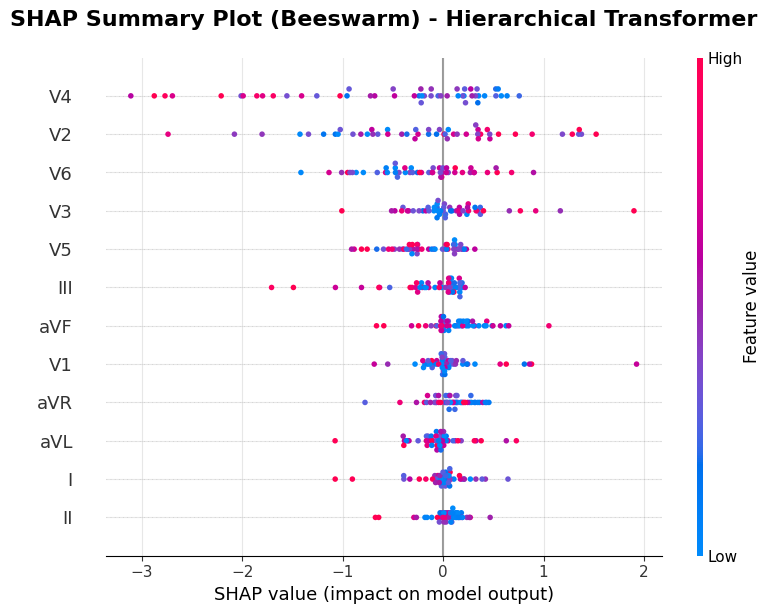

In [28]:
# Visualisasi SHAP Beeswarm Plot (Summary Plot)
print("\n📊 Generating SHAP Beeswarm Summary Plot...")

# Untuk merangkum fitur time-series (N, 12, L) menjadi (N, 12) untuk beeswarm plot:
# 1. SHAP Impact (X-axis): Total net impact dari lead tersebut pada prediksi (sum over time)
shap_vals_2d = shap_vals.sum(axis=2) 

# 2. Feature Value (Color): Kekuatan sinyal aktual dari lead tersebut (menggunakan standar deviasi / amplitudo)
exp_data_np = exp_data.cpu().numpy()
features_2d = np.std(exp_data_np, axis=2)

fig = plt.figure(figsize=(12, 8))
# Tampilkan beeswarm plot dari library SHAP
shap.summary_plot(shap_vals_2d, features=features_2d, feature_names=LEADS, show=False)
plt.title(f'SHAP Summary Plot (Beeswarm) - {best_model_name}\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'shap_summary_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Ringkasan & Simpan Hasil

In [29]:
print("\n" + "=" * 70)
print("💾 MENYIMPAN HASIL")
print("=" * 70)

df_comparison.to_csv(OUTPUT_DIR / 'kfold_comparison.csv', index=False)
print(f"   ✅ K-Fold comparison: {OUTPUT_DIR / 'kfold_comparison.csv'}")

test_res_df = pd.DataFrame([
    {'level': 'segment', **test_metrics},
    {'level': 'patient', **patient_metrics}
])
test_res_df.to_csv(OUTPUT_DIR / 'final_test_results.csv', index=False)
print(f"   ✅ Final test results: {OUTPUT_DIR / 'final_test_results.csv'}")

lead_imp_df.to_csv(OUTPUT_DIR / 'lead_importance.csv', index=False)
print(f"   ✅ Lead importance: {OUTPUT_DIR / 'lead_importance.csv'}")

with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump({k: str(v) if isinstance(v, list) else v for k, v in CONFIG.items()}, f, indent=2)

final_state = {k: v.cpu().clone() for k, v in final_model.state_dict().items()}
torch.save(final_state, OUTPUT_DIR / f'final_model_{best_model_name.replace(" ", "_")}.pth')
print(f"   ✅ Final model saved.")


💾 MENYIMPAN HASIL
   ✅ K-Fold comparison: baseline_results/kfold_comparison.csv
   ✅ Final test results: baseline_results/final_test_results.csv
   ✅ Lead importance: baseline_results/lead_importance.csv
   ✅ Final model saved.


In [30]:
print("\n" + "=" * 70)
print("📋 RINGKASAN NOTEBOOK 02: BASELINE CNN-TRANSFORMER")
print("=" * 70)

print(f"""
🔬 PIPELINE:
   DATA DWT → 80/20 Split → 5-Fold CV (Penguat) → 100% Training Model Final → Test (20% DWT) → SHAP

🏆 PERBANDINGAN MODEL K-FOLD (F1-Score):
   1. {MODEL_NAMES[0]:<25}: {df_comparison.loc[0, 'f1_mean']:.3f} ± {df_comparison.loc[0, 'f1_std']:.3f}
   2. {MODEL_NAMES[1]:<25}: {df_comparison.loc[1, 'f1_mean']:.3f} ± {df_comparison.loc[1, 'f1_std']:.3f}
   3. {MODEL_NAMES[2]:<25}: {df_comparison.loc[2, 'f1_mean']:.3f} ± {df_comparison.loc[2, 'f1_std']:.3f}

🏅 FINAL MODEL: {best_model_name} (Dilatih ulang selama {best_avg_epoch} epochs)

🧪 FINAL TEST (20% DWT Data) — Patient Level:
   • Accuracy   : {patient_metrics['accuracy']:.3f}
   • Sensitivity: {patient_metrics['sensitivity']:.3f}
   • Specificity: {patient_metrics['specificity']:.3f}
   • F1-Score   : {patient_metrics['f1']:.3f}
   • AUC-ROC    : {patient_metrics['auc']:.3f}

🔍 SHAP TOP-3 LEADS: {', '.join(lead_imp_df.head(3)['Lead'].values)}

🔜 LANGKAH SELANJUTNYA:
   → Notebook 3: Fine-Tuning (GAN augmentation → Grid Search → CNN-Transformer)
""")

print("✅ Notebook 02 Baseline CNN-Transformer (2-Stage Training) SELESAI!")


📋 RINGKASAN NOTEBOOK 02: BASELINE CNN-TRANSFORMER

🔬 PIPELINE:
   DATA DWT → 80/20 Split → 5-Fold CV (Penguat) → 100% Training Model Final → Test (20% DWT) → SHAP

🏆 PERBANDINGAN MODEL K-FOLD (F1-Score):
   1. Transformer Encoder      : 0.942 ± 0.014
   2. PatchTST                 : 0.944 ± 0.011
   3. Hierarchical Transformer : 0.947 ± 0.016

🏅 FINAL MODEL: Hierarchical Transformer (Dilatih ulang selama 9 epochs)

🧪 FINAL TEST (20% DWT Data) — Patient Level:
   • Accuracy   : 0.866
   • Sensitivity: 0.885
   • Specificity: 0.800
   • F1-Score   : 0.911
   • AUC-ROC    : 0.944

🔍 SHAP TOP-3 LEADS: V2, V4, V6

🔜 LANGKAH SELANJUTNYA:
   → Notebook 3: Fine-Tuning (GAN augmentation → Grid Search → CNN-Transformer)

✅ Notebook 02 Baseline CNN-Transformer (2-Stage Training) SELESAI!
